<a target="_blank" href="https://colab.research.google.com/github/TUIlmenauAMS/Videocoding/blob/main/LecturesJupterNotebooks/Lecture4/Lecture4.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

<font size="8" color ="Brown"><center>
# Lecture 4, Video Coding, Irrelevance Reduction, Transforms
        
</center></font>
<br>

<p style="line-height:1.5">
<font size="6">We saw: we have many more light sensitive sensors (rods, cones) than we have optical nerve fibers into the brain. This means the retina does some pre-processing to obtain a compression. It does this by spatial filtering. The basic system can be seen in the following picture:<br>

![Lecture4-1.PNG](https://github.com/TUIlmenauAMS/Videocoding/blob/main/LecturesJupterNotebooks/Lecture4/Img-Lecture4/Lecture4-1.PNG?raw=1)
<br>
**Weber's Law:**  $ \frac{\Delta w} {w} = konst $<br><br>
- states that the ratio of the increment threshold to the background intensity is a constant.<br>
- measurement of increment thresholds on various intensity backgrounds, the thresholds increase in proportion to the background. <br>
<br>
The weights are part of what is called **“receptive fields”** in the retina, and they are comparable to our filter kernel. The resulting spatial frequency response of this system is the co-called Contrast Sensitivity function of the eye:

![Lecture4-2.PNG](https://github.com/TUIlmenauAMS/Videocoding/blob/main/LecturesJupterNotebooks/Lecture4/Img-Lecture4/Lecture4-2.PNG?raw=1)

The CSF measures the sensitivity of the eye for different spatial frequencies.<br>
The contrast is defined as follows: The maximum light intensity is $L_{max}$, and the minimum intensity $L_{min}$. Then the so-called “Michaelson Contrast” is<br>
$$
c=\frac{ L_{max}-L_{min} } { L_{max}+L_{min} }
$$
The contrast sensitivity has $1/c$ on its vertical axis.
<br><br>
The following shows a sketch to visualize spatial frequencies:

<br>

![Lecture4-3.PNG](https://github.com/TUIlmenauAMS/Videocoding/blob/main/LecturesJupterNotebooks/Lecture4/Img-Lecture4/Lecture4-3.PNG?raw=1)
<br>
An example for an image with different pure spatial frequencies with different contrasts can be seen in following picture. On the left hand side are low spatial frequencies, right are high frequencies. On the lower side are high contrasts, on the higher side are low contrasts:<br><br>

![Lecture4-4.PNG](https://github.com/TUIlmenauAMS/Videocoding/blob/main/LecturesJupterNotebooks/Lecture4/Img-Lecture4/Lecture4-4.PNG?raw=1)
<br>
Observe: cameras also have this type of transfer function, but there it is called “Modulation Transfer Function” (MTF). This type of function is independent on the type of imaging sensor, for instance you can also have a MTF for ultra sound images, or X-ray images. Spatial frequencies have no time unit in them, just spatial units (degree).<br><br>

The eye has different CSF for luminance and chrominance (color), mainly because of the different number of sensors. It also has a limited temporal speed. Both can be seen in following picture:<br>
<br>
![Lecture4-5.PNG](https://github.com/TUIlmenauAMS/Videocoding/blob/main/LecturesJupterNotebooks/Lecture4/Img-Lecture4/Lecture4-5.PNG?raw=1)
<br>
![Lecture4-6.PNG](https://github.com/TUIlmenauAMS/Videocoding/blob/main/LecturesJupterNotebooks/Lecture4/Img-Lecture4/Lecture4-6.PNG?raw=1)
<br>
These measurements where made with test subjects, which tested which patterns can be seen. Hence this most likely reflects the properties in the area of the sharpest vision, the fovea.

<br><br><br>

How can these effects be used in video coding?
<br><br><br>

Since the eye has different sensitivities for different spatial frequencies, we need to decompose our images or frames into subbands with different spatial frequencies and quantize them with an accuracy which is suitable to the sensitivity for the eye at the spatial frequency of the subband.
<br><br>
We already saw that we can obtain a frequency decomposition of our frames using the 2D DFT. But this is not the only method, and as we will see not the optimum method for image and video coding. The 2D DFT is a special case of a **block transform**, which in turn is a special case of a **filter bank**  with sampling.
<br>

</font></p>    

<font size="8" color ="Brown"><center>

# Transform Coding
</center></font>
<br>

<p style="line-height:1.5">
<font size="6">

After motion compensation (in the block “image encoder” which we will still see) we **usually apply the DCT to** blocks of the prediction error image, or directly on the image.<br>
We apply transform coding to our image, or the prediction error image, with the goal to **minimize the number of bits** needed for transmitting or storing this image. Transform coding can be viewed as being part of the redundancy reduction and also the **irrelevance reduction**. In this way it is an addition to the predictive coding (e.g. with motion compensation), or can also be used as an alternative. But unlike the predictive coding, for transform coding we can also use psycho-optical effects, because we can take advantage of the different sensitivities of our eye to different spacial frequencies, as signified by the **Contrast Sensitivity Function** of the eye. This is possible because the transform delivers different subbands at different spacial frequencies, which we can then be encoded with adapted accuracy (adapted to the CSF).<br>
So far we have mainly redundancy reduction with our predictive coding, and now we can also use more **irrelevance reduction** in this way.<br><br>
The basic principle of applying transforms to our images or prediction error images is, to first subdivide our image into blocks (for instance size 8x8 pixels), and then apply our transform to each block. Usually we use a so-called separable transform (meaning it is defined only for 1 dimension, like a DFT or a DCT), which is then applied first to one dimension (for instance the rows). The result is then used to apply the transform to the other dimension, like the columns.
<br><br>
</font></p>    

<font size="8" color ="Brown"><center>
## Equivalence of Transforms and Critical Sampled Filter Banks
</center></font>
<br>
<p style="line-height:1.5">
<font size="6">
    
A **critical sampled filter bank** is a filter bank, where the **downsampling factor is identical to the number of subbands**. This was the case for instance in 2 band decompostion of an image. We have 2 bands, and also a downsampling factor of 2. How does the transform and its connection to filter banks look mathematically?

</font></p>    

<font size="8" color ="Brown"><center>
# Transforms
        
</center></font>
<br>

<p style="line-height:1.5">
<font size="6">
    
The  DFT of a block of signal x (for instance a row of our image block), which starts at sample $x(mN)$, and has length N, is defined as <br>
$$
X_m(k) =\sum_{n= 0} ^ {N-1} x(mN+n) e ^{-j 2\frac{\pi} { N}.k.n}
$$
<br>
Now we can rewrite the  DFT as a matrix multiplication with the matrix $T$ with the elements,<br>
$$
\boldsymbol {T} _{n,k}=e ^{-j \frac{2 \pi}  {N}.n.k}
$$
<br>
n is the time and row index, and k is the frequency and column index. Using the block vector<br>
$$
\boldsymbol x (m)=[x(mN),x(mN+1), ..., x(mN+N-1)]
$$  (eq:1)<br>
we can rewrite the DFT of block m as a matrix multiplication,<br>
$$
\boldsymbol y (m) = \boldsymbol x (m). \boldsymbol T
$$
<br>
This is the matrix formulation of the DFT
<br><br>
Take this **transform matrix** $\boldsymbol T$, which contains the coefficients of our transform (for instance a DCT matrix, where each column contains the coefficients of a different subband filter), and a **block of the image** $\boldsymbol x$ , for instance containg the 8x8 pixels (we use boldface letters for matrices and vectors). <br>
If we want to apply this transform to the **rows** of the image, we have to multiply the transform matrix $\boldsymbol T$ **from the right** $\boldsymbol x.\boldsymbol T$, (each row of $\boldsymbol x$ is multiplied by $\boldsymbol T$ ). Each **column** of $\boldsymbol T$ can now be seen as a **different filter** for a subband. Assume we have subbands $N$, then we have filters with impulse responses $h_k(n)$, where k is the subband index $(k=0,...,N-1)$, and n is the time or space index of the impulse response ($n=0,...,N-1$, because we have a **square matrix** for **invertibility** or perfect reconstruction, which limits the length of our filters to N). Hence our matrix has the form<br>

![Lecture4-7.PNG](https://github.com/TUIlmenauAMS/Videocoding/blob/main/LecturesJupterNotebooks/Lecture4/Img-Lecture4/Lecture4-7.PNG?raw=1)<br>

Observe that the impulse responses appear in **reverse order!**

<br><br>


If we multiply this matrix from the right side on our block $\boldsymbol x$, we multply each row of x with each column of $\boldsymbol T$. This vector multiplication of one signal row with one colmn of the transform (containing the impulse response of one filter) is **mathematically identical to the convolution** of the signal with this filter, but where we only obtain one value of this convolution (we get one value for each vector multiplication of one row of x with one column of $\boldsymbol T$). Because we only get one value for each subband for one block (instead of for each sample), we already have (implicitly) included the **downsampling** of the equivalent filter bank. In this way we get one value for each row of $\boldsymbol x$ and each subband of $\boldsymbol T$, for a total of NxN values. This can also be seen if we look at the matrix multiplication: we obtain a square result matrix of size NxN.
<br><br>
The following image depicts a 1-D filter bank, for instance along the rows, with **critical sampling** (down sampling rate equal to the number of subbands):
with<br>


![Lecture4-8.PNG](https://github.com/TUIlmenauAMS/Videocoding/blob/main/LecturesJupterNotebooks/Lecture4/Img-Lecture4/Lecture4-8.PNG?raw=1)<br>
$$
y_k(m)=\sum _{n=0} ^\infty x(mN-n) .h_k(n)
$$
(m is the block index). Observe that this is a **convolution** equation, except for the factor of N behind the block index m. This factor results from the **downsampling** with the factor N.

<br><br>

Compare this with the transform equation from above,
$$
X_m(k) =\sum _{n= 0} ^{N-1} x(mN+n) e ^{-j \frac{2\pi}{ N }.k.n}
$$
<br>
for the comparison we assume that the filter $h_k(n)$ is only of length N, hence the convolution sum for $y_k(m)$ only goes up to N-1. Then we replace the index n in the transform equation by N-1-n'. We get<br>
$$
X_m( k )=y_k( m )= \sum _ { n'=0 } ^{ N-1 } x( mN+N-1-n' ) .e^{ j \frac{2 \pi } {N} .(N-1-n') . k }
$$
<br>
This now corresonds to the convolution equation for $y_k(m)$ but with a shift of N-1 samples in the signal x, and with the **equivalent impulse response** of

$$
h_k( n )=e^{ j 2 \frac{\pi} { N} .(N-1-n) .k }
$$
<br>

This shows why the analysis transform matrix contains the impulse responses of the equivalent filters, but in **reverse order**
<br><br
This approach now shows, that applying the transform is identical to a filter bank with critical sampling, but with the **restriction** that the filters have to be of **length N** (otherwise we would not have an invertible square matrix). This means the **transform** is a **special case of a filter bank**  with critical sampling.

<br><br>

So for the rows we get<br>
$$\boldsymbol x'=\boldsymbol x .  \boldsymbol T$$
We still need to apply our transform to the **columns**. To obtain this, we simply multiply the transpose of our transform matrix from the left hand side,<br>
$$\boldsymbol y := \boldsymbol T^T . \boldsymbol x'$$
or, taking both steps together,
<br>
$$\boldsymbol y = \boldsymbol T ^T .\boldsymbol x . \boldsymbol T$$
$y$ now contains the frequency domain coefficients of our image block $x$.
Writing the transform as the matrix multiplication has the big advantage, that we can easily take the inverse transform for the **decoder**,<br>
$$
\boldsymbol x = \boldsymbol T^{-T} . \boldsymbol y.\boldsymbol T^{-1}
$$
where $.^{-T}$ is the inverse of the transpose. In this way we get easily the perfect reconstruction in the decoder.<br>
**Example:** The DCT Type 2 is defined as


<br><br>

$$
T_{ n,k }=\frac{1 }{ \sqrt N }.  cos( \frac{\pi }{N} .(n+0.5). k )$$
for $n,k=0,...,N-1.$
</font></p>    



<font size="8" color ="Brown"><center>
## Python Example:
        
<center></font>
<br>

<p style="line-height:1.5">
<font size="6">Take a 4x4 block of an image, for instance a part of a somewhat dark and even background:

</font></p>    

In [ ]:
import numpy as np
x=0.3*np.ones((4,4))
x

array([[0.3, 0.3, 0.3, 0.3],
       [0.3, 0.3, 0.3, 0.3],
       [0.3, 0.3, 0.3, 0.3],
       [0.3, 0.3, 0.3, 0.3]])


<p style="line-height:1.5">
<font size="6">
Now transform this block x. First compute the transform matrix $\boldsymbol T$, which in this example is a so-called DCT type 2. First we obtain the transform matrix T by applying the DCT to the identity matrix I (norm=’ortho’ includes the square root term):
</font></p>    

In [ ]:
import scipy.fftpack
I=np.eye(4)
I


array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]])

In [ ]:
T=scipy.fftpack.dct(I,norm='ortho')
T


array([[ 0.5       ,  0.65328148,  0.5       ,  0.27059805],
       [ 0.5       ,  0.27059805, -0.5       , -0.65328148],
       [ 0.5       , -0.27059805, -0.5       ,  0.65328148],
       [ 0.5       , -0.65328148,  0.5       , -0.27059805]])


<p style="line-height:1.5">
<font size="6">
    
Here we can see that each column represents a filter. <br>
For instance our filter impulse response (the coefficients) for the lowest subband, (including flipping it up-down) is
    
</font></p>    

In [ ]:
h0=np.flipud(T[:,0])
h0


array([0.5, 0.5, 0.5, 0.5])

<p style="line-height:1.5">
<font size="6">Now we can transform our block to obtain our 2-dimensional subband values ,
</font></p>

In [ ]:
y=np.dot(np.dot(np.transpose(T),x),T)
y


array([[1.2, 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. ]])

<p style="line-height:1.5">
<font size="6">
    
**Observe:** We have only **1 large value,** the 1.2, in the upper, left hand corner. This corresponds to filter $h_0(0)$ horizontally and vertically. The rest of the coefficients is zero. For natural images, the DCT usually has this effect, that the large values appear in the upper, left hand corner, and the rest of the values are much smaller. This property is also called **"energy compaction"**, and is used to reduce the bit rate, by taking advantage of redundancies in our signal, the image block. For instance, many consecutive zeros can be efficiently and easily encoded using the run-length coding (an escape code, followed by the value and the number of repetitions).
</font></p>

<font size="8" color ="Brown"><center>
## Python Video Example
        
<center></font>
<br>

<p style="line-height:1.5">
<font size="6">The following example show a live video where the frames are DCT2 transformed, and the magnitude of the DCT coefficients displayed:
You can also run this example with following command in terminal.

```
    python videorecdctdisp.py
```
</font></p>    

In [3]:
import cv2
import numpy as np

# Initialize video capture object
cap = cv2.VideoCapture(0) # 0 for default camera

# Check if camera opened successfully
if not cap.isOpened():
    print("Error: Could not open video stream.")
else:
    # Define the codec and create VideoWriter object
    fourcc = cv2.VideoWriter_fourcc(*'XVID') # You can try other codecs like 'MJPG', 'mp4v'
    fps = 20.0 # Frames per second
    duration = 1 # seconds
    num_frames_to_record = int(fps * duration)

    # Get default frame width and height
    frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    out = cv2.VideoWriter('output.avi', fourcc, fps, (frame_width, frame_height))

    print(f"Recording {duration} second(s) of video at {fps} fps...")

    frames_recorded = 0
    while(cap.isOpened() and frames_recorded < num_frames_to_record):
        ret, frame = cap.read()
        if ret == True:
            out.write(frame)
            frames_recorded += 1
            # Optional: Display the recording live
            cv2.imshow('Recording...', frame)
            if cv2.waitKey(1) & 0xFF == ord('q'): # Press 'q' to stop early
                break
        else:
            break

    # Release everything if job is finished
    cap.release()
    out.release()
    cv2.destroyAllWindows()
    print(f"Video recording complete. Saved to output.avi ({frames_recorded} frames recorded).")

Error: Could not open video stream.


### Colab Webcam Recording Workaround

Since `cv2.VideoCapture(0)` cannot access your local webcam directly in the Colab environment, we use a JavaScript-based workaround. This code will use JavaScript in your browser to capture video frames and send them back to the Python kernel, where they can then be processed and saved using OpenCV.

In [4]:
# Install Pillow for image decoding if not already installed
!pip install Pillow

In [6]:
import cv2
import numpy as np
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
from PIL import Image
import io

def record_video_colab(duration=1, fps=20):
    js_code = Javascript('''
        async function startVideoCapture() {
            const video = document.createElement('video');
            video.style.display = 'none'; // Hide the video element
            document.body.appendChild(video);

            const stream = await navigator.mediaDevices.getUserMedia({video: true});
            video.srcObject = stream;
            await video.play();

            // Resize the canvas to match video dimensions
            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            const context = canvas.getContext('2d');

            let frames = [];
            let frameCount = 0;
            const maxFrames = ''' + str(int(duration * fps)) + '''; // Number of frames to capture

            return new Promise((resolve) => {
                const interval = setInterval(() => {
                    if (frameCount < maxFrames) {
                        context.drawImage(video, 0, 0, canvas.width, canvas.height);
                        const dataUrl = canvas.toDataURL('image/jpeg', 0.8); // 0.8 quality
                        frames.push(dataUrl.split(',')[1]); // Only send the base64 data
                        frameCount++;
                    } else {
                        clearInterval(interval);
                        stream.getVideoTracks()[0].stop();
                        document.body.removeChild(video);
                        resolve(frames);
                    }
                }, 1000 / ''' + str(fps) + '''); // Capture at specified FPS
            });
        }
        startVideoCapture();
    ''')

    print("Granting webcam access and recording...")
    display(js_code)

    # The JavaScript returns an array of base64 encoded images.
    # eval_js executes the JS and returns the result.
    # It's important to call the function defined in the JS code.
    base64_frames = eval_js('startVideoCapture()')

    print(f"Captured {len(base64_frames)} frames. Processing...")

    if not base64_frames:
        print("No frames captured. Please ensure you granted camera access.")
        return

    # Decode the first frame to get dimensions and initialize video writer
    img_bytes = b64decode(base64_frames[0])
    img_np = np.array(Image.open(io.BytesIO(img_bytes)))
    height, width, _ = img_np.shape

    # Define the codec and create VideoWriter object
    fourcc = cv2.VideoWriter_fourcc(*'MJPG') # MJPG is a good option for AVI for wider compatibility
    out = cv2.VideoWriter('output_colab_webcam.avi', fourcc, fps, (width, height))

    if not out.isOpened():
        print("Error: Could not open video writer. Check permissions or codec availability.")
        return

    # Write all captured frames to the video file
    for i, base64_frame in enumerate(base64_frames):
        try:
            img_bytes = b64decode(base64_frame)
            img_np = np.array(Image.open(io.BytesIO(img_bytes)))
            # OpenCV expects BGR format, PIL (Image.open) gives RGB
            frame_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)
            out.write(frame_bgr)
        except Exception as e:
            print(f"Error processing frame {i}: {e}")
            continue

    out.release()
    print(f"Video recording complete. Saved to output_colab_webcam.avi ({len(base64_frames)} frames recorded).")

# Call the function to record a 1-second video at 20 frames per second
record_video_colab(duration=1, fps=20)

Granting webcam access and recording...


<IPython.core.display.Javascript object>

Captured 20 frames. Processing...
Video recording complete. Saved to output_colab_webcam.avi (20 frames recorded).


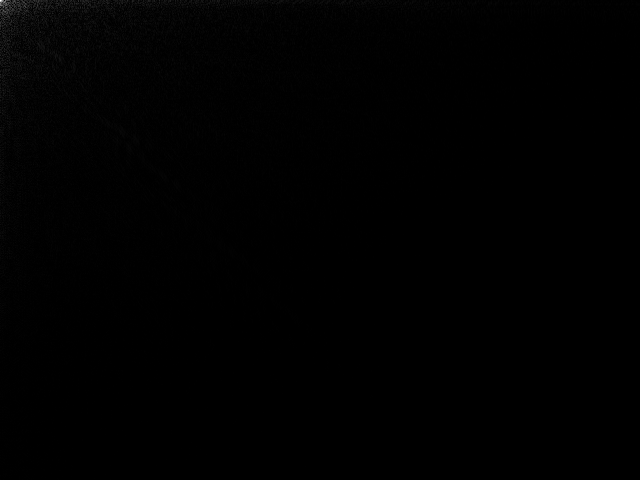

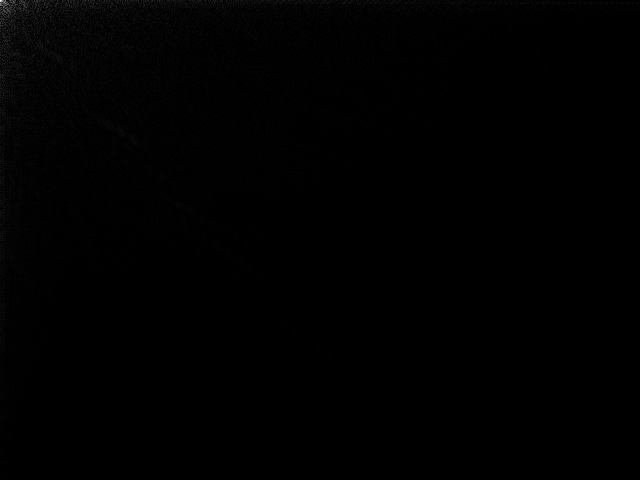

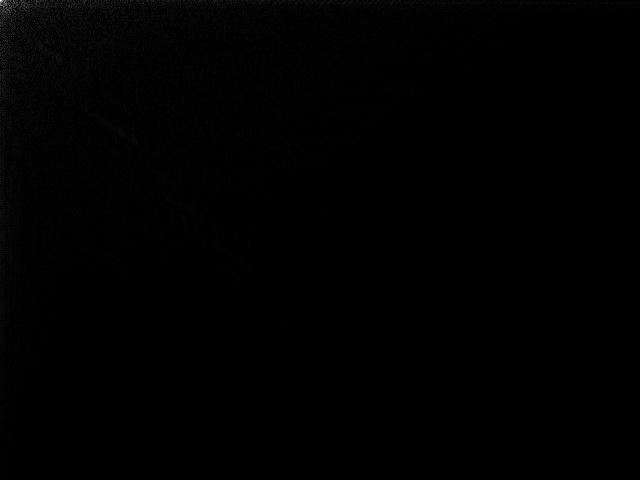

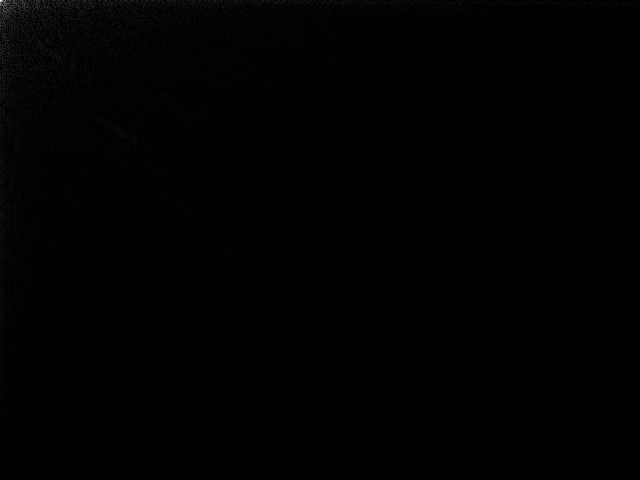

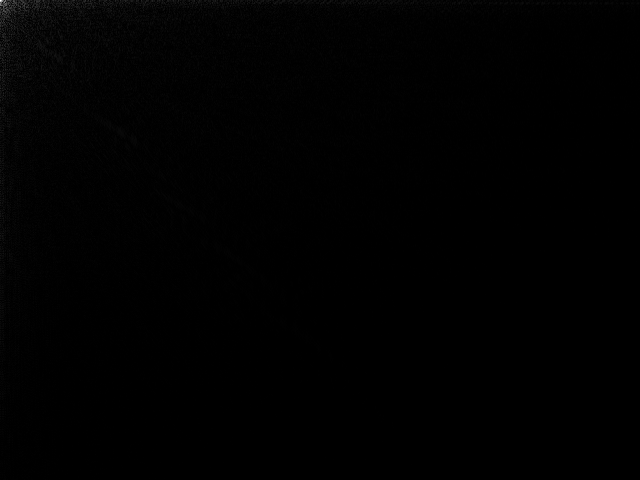

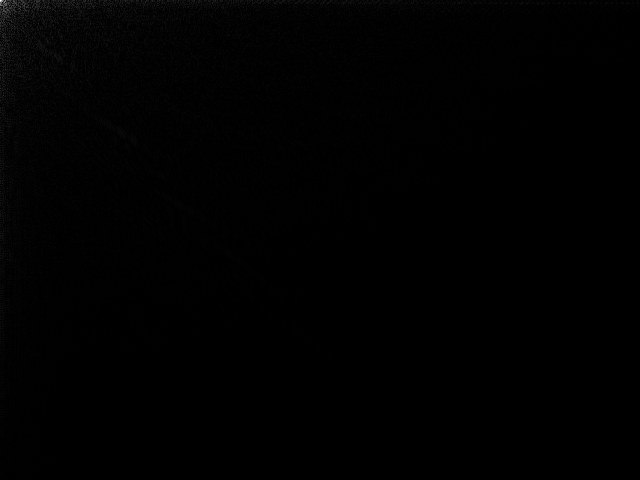

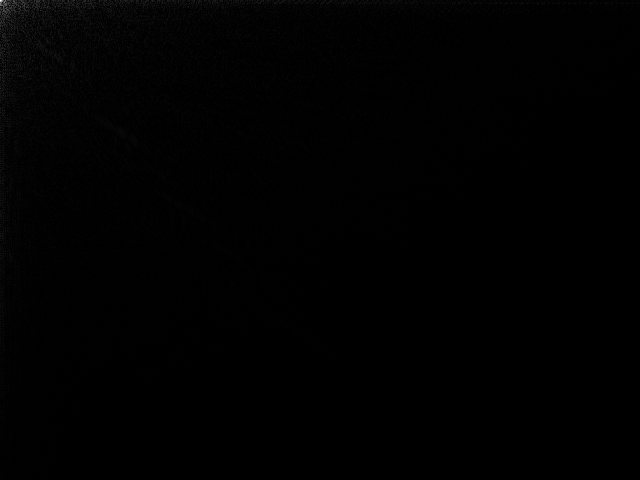

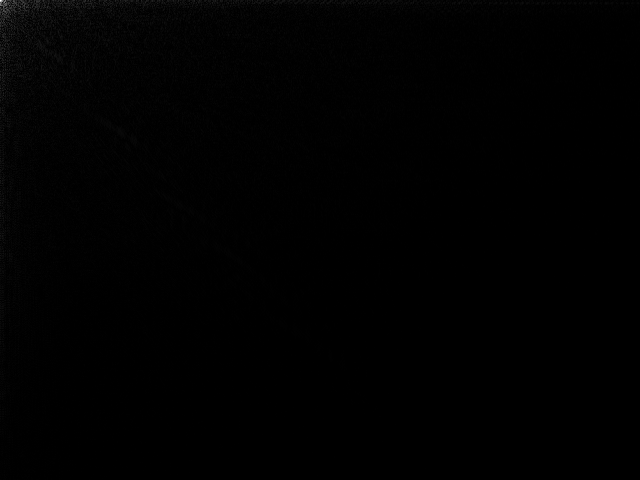

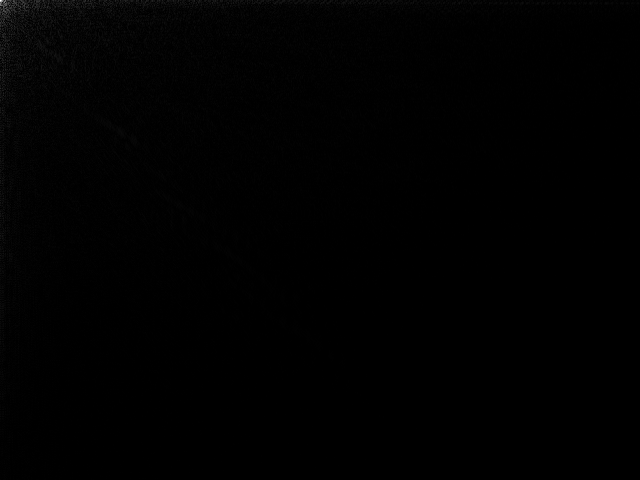

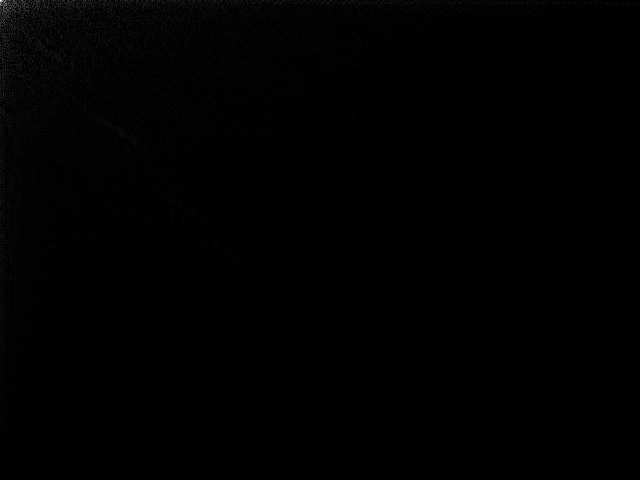

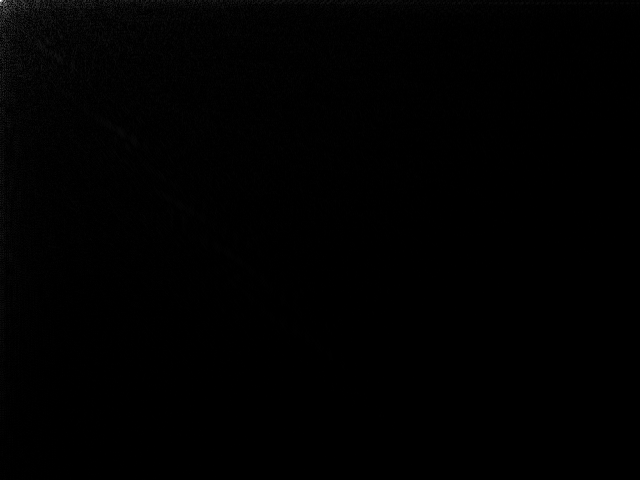

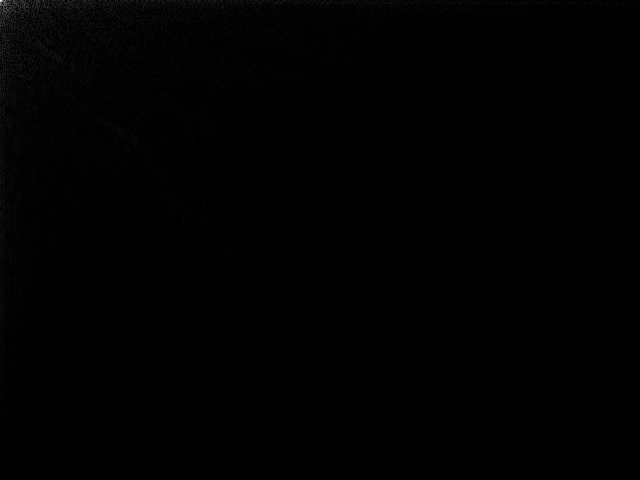

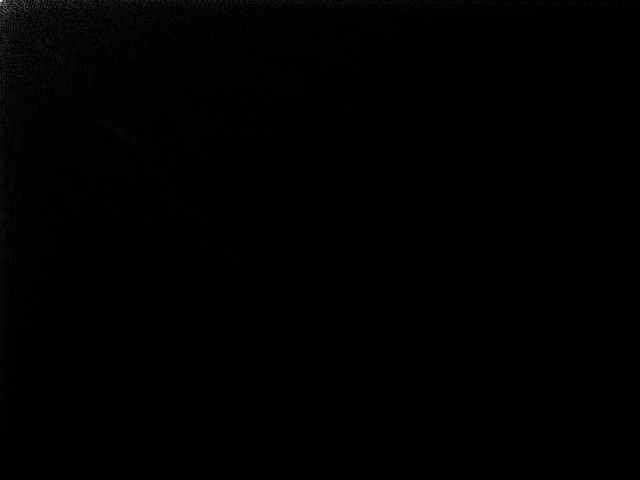

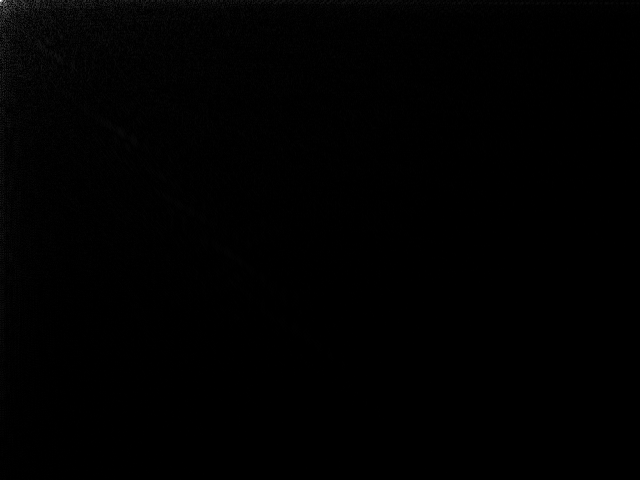

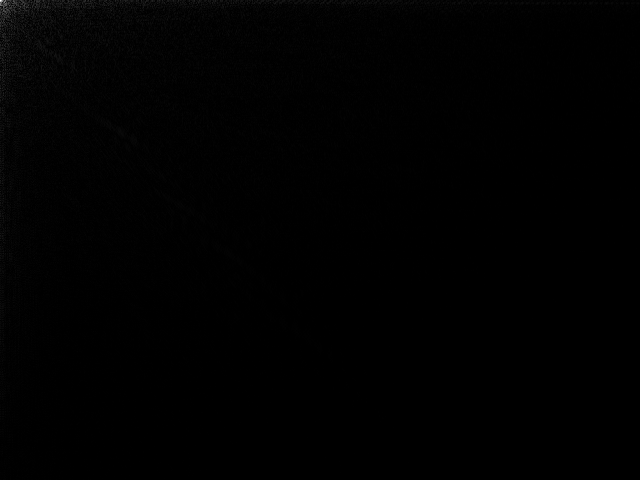

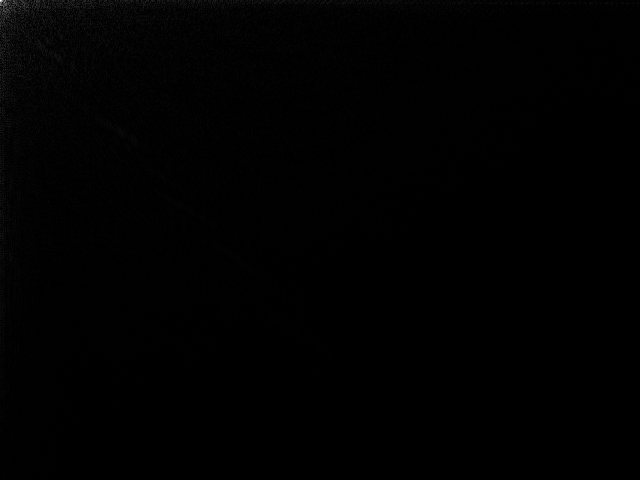

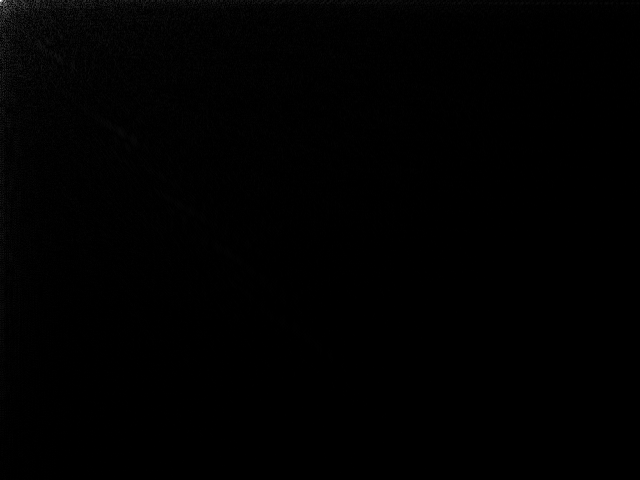

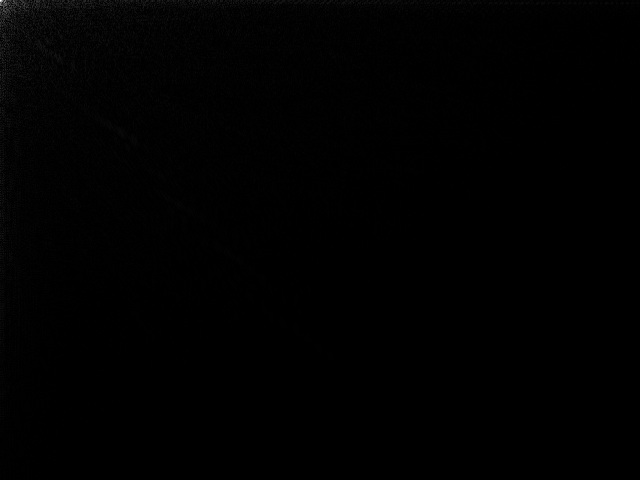

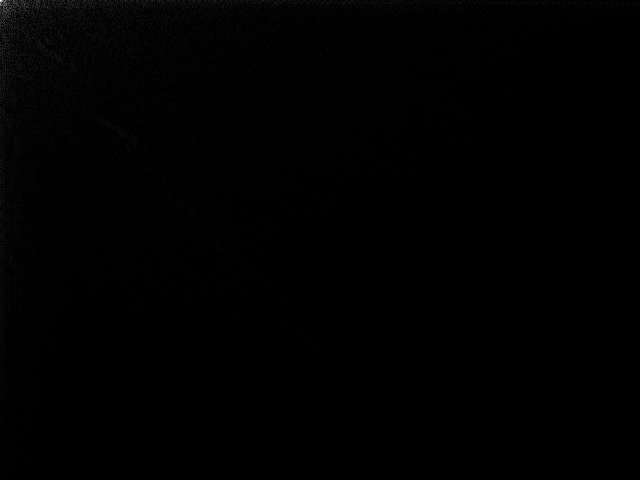

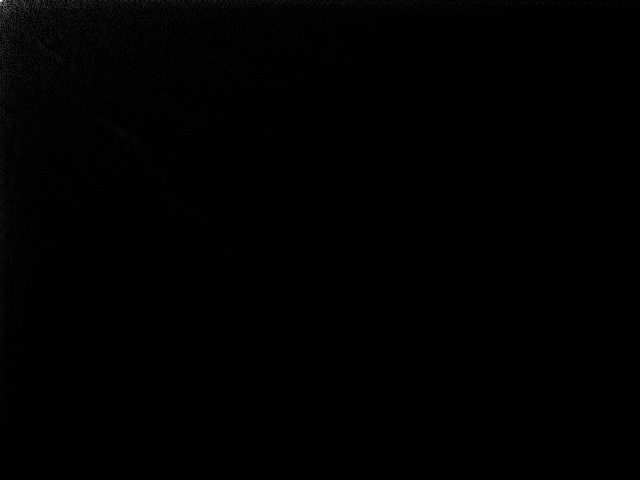

In [11]:
#Program to capture a video from the default camera (0), compute the 2D DCT Type 2
#on the Green component, take the magnitude (phase) and display it live on the screen
#Gerald Schuller, Nov. 2014
import cv2
import numpy as np
import scipy.fftpack as sft
from google.colab.patches import cv2_imshow # Import cv2_imshow for Colab compatibility

# Change to load the previously recorded video file
cap = cv2.VideoCapture('output_colab_webcam.avi')

# Check if video file opened successfully
if not cap.isOpened():
    print("Error: Could not open video file.")
else:
    while(True):
        # Capture frame-by-frame
        ret, frame = cap.read()

        # Break the loop if there are no more frames
        if not ret:
            break

        #compute magnitude of 2D DCT of green component
        #by applying the DCT first along the rows and the along the columns,
        #with suitable normalization for the display:
        # Ensure frame is not None before processing
        if frame is not None:
            # Convert to grayscale first, then take green component if it's RGB/BGR
            # Assuming the video frames are BGR, we can extract the green channel directly.
            # If it's a grayscale video, frame will be 2D.
            if len(frame.shape) == 3:
                green_component = frame[:,:,1]
            else:
                green_component = frame # It's already grayscale

            # Apply DCT
            dct_rows = sft.dct(green_component / 255.0, axis=1, norm='ortho')
            dct_2d = np.abs(sft.dct(dct_rows, axis=0, norm='ortho'))

            # Apply logarithmic scaling for better visualization of frequency components
            # Add a small constant (e.g., 1) before log to avoid log(0) and to make small values visible
            log_dct_2d = 20 * np.log10(1 + dct_2d)

            # Normalize the log-scaled data to 0-255 for display
            max_log_val = np.max(log_dct_2d)
            if max_log_val > 0:
                display_frame = (log_dct_2d / max_log_val * 255).astype(np.uint8)
            else:
                display_frame = np.zeros_like(log_dct_2d, dtype=np.uint8)

            # Display the resulting frame using cv2_imshow
            cv2_imshow(display_frame)

        #Keep window open until key 'q' is pressed:
        # Note: cv2.waitKey is still used for delaying frames, but it won't exit on 'q'
        # as cv2_imshow renders static images. To stop, you'll need to manually stop execution.
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    # When everything done, release the capture
    cap.release()
    # cv2.destroyAllWindows() is not strictly needed with cv2_imshow

<p style="line-height:1.5">
<font size="6">
**Observe:** Bright points, corresponding to **large coefficients**, mostly appear in the **upper left hand corner**, and no longer in all 4 corners as with the DFT. We no longer have the symmetry around the center of the frame. Since we now no longer have 2 copies of our spectrum, the 2D DCT uses our pixels to **finer describe** this one copy of our 2D-spectrum.<br>
If we hold a **fine pattern** in front of the camera, **larger coefficients** also appear **towards the center** of the 2D spectrum, depending on the pattern, as with the DFT.<br><br>

The **next example** shows what happens if we set most of the higher frequency DCT coefficients to zero, and then apply the inverse DCT to obtain our frame back:<br><br>

```
    python videorecdct0idctdisp.py
```
</font></p>

In [ ]:
#Program to capture a video from the default camera (0), compute the 2D FFT
#on the Green component, take the magnitude (phase) and display it live on the screen
#apply a 2D DCT , low pass filter, and iverse transform.
#Gerald Schuller, Nov. 2014
import cv2
import numpy as np
import scipy.fftpack as sft

cap = cv2.VideoCapture(0)
#Get size of frame:
[retval, frame] = cap.read()
[r,c,d]=frame.shape
print(r,c)

#Mask to set to zero the 3/4 highest frequencies,
#only kep the 1/4 lowest frequencies in each direction for the DCT,
#because of the DCT no longer symmetric about the center:

#For rows:
Mr=np.ones((r,1))
Mr[int(r/4.0):r,0]=np.zeros(int(3.0/4.0*r))
#For columns:
Mc=np.ones((1,c))
Mc[0,int(c/4.0):c]=np.zeros(int(3.0/4.0*c));
#Together:
M=np.dot(Mr,Mc)

while(True):
    # Capture frame-by-frame
    [retval, frame] = cap.read()
    cv2.imshow('Original Video, Gruen Komponente',frame[:,:,1])

    #compute magnitude of 2D DCT of green component
    #with suitable normalization for the display,
    #with norm='ortho' for "energy conservation" in the subbands and for
    #invertibiltity without factor:
    X=sft.dct(frame[:,:,1]/255.0,axis=1,norm='ortho')
    X=sft.dct(X,axis=0,norm='ortho')
    #Set to zero the 7/8 highest spacial frequencies in each direction:
    X=X*M
    frame=np.abs(X)

    # Display the resulting frame
    cv2.imshow('2D-DCT with setting to zero the highest spatial frequencies',frame)
    #Inverse 2D DCT:
    X=sft.idct(X,axis=1,norm='ortho')
    x=sft.idct(X,axis=0,norm='ortho')
    cv2.imshow('Inverse 2D DCT without the highest spatial frequencies', x)

    #Keep window open until key 'q' is pressed:
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
# When everything done, release the capture
cap.release()
cv2.destroyAllWindows()


480 640


<p style="line-height:1.5">
<font size="6">

**Observe:** even though we set **most** of our DCT coefficients to **zero**, the reconstructed frame **still looks good**, just a little unsharp. This means this is a **powerful method to compress** our frames!
<br><br><br>
Example for applying the DCT- zero-setting of the high frequency coefficient- inverse DCT to **blocks of size 8x8 pixels:**
<br>
```
python videorecdctblocks0idctdisp.py
```
</font></p>

In [ ]:
#Program to capture a video from the default camera (0), compute the 2D DCT
#on the Green component, take the magnitude (phase) and display it live on the screen, divide the picture into blocks
#of 8x8 pixels and apply a 2D DCT to each, low pass filter, and inverse transform.
#Gerald Schuller, Nov. 2014

import cv2
import numpy as np
import scipy.fftpack as sft

cap = cv2.VideoCapture(0)
#Get size of frame:
[retval, frame] = cap.read()
[r,c,d]=frame.shape
print(r,c)

#Mask to set to zero the 3/4 highest frequencies,
#only kep the 1/4 lowest frequencies in each direction for the 8x8 DCT,
#because of the DCT no longer symmetric about the center:

#For rows:
Mr=np.ones(8)
Mr[int(8/4.0):r]=np.zeros(int(3.0/4.0*8))
#For columns:
Mc=Mr;

#Grid of 8x8 blocks:
gc=np.zeros((1,c))
gc[0,0:c:8]=np.ones(int(c/8))
gr=np.zeros((r,1))
gr[0:r:8,0]=np.ones(int(r/8))
grid=np.ones((r,1))*gc+gr*np.ones((1,c))
#print(grid[0:9,0:9])

while(True):
    # Capture frame-by-frame
    [retval, frame] = cap.read()

    cv2.imshow('Original Video, Green Component, with superimposed 8x8 grid',frame[:,:,1]/255.0+grid)
    #cv2.imshow('Original Video, Gruen Komponente',frame[:,:,1])

    #compute magnitude of 2D DCT of blocks of 8x8 pixels of the green component
    #by first reshaping the image to width 8 and applying the 1D DCT all rows, then reshape it back,
    #then transpose it, and again reshape it to width 8 and apply the 1D DCT to each row, reshape it back,
    #and transpose it back.
    #with norm='ortho' for "energy conservation" in the subbands and for
    #invertibiltity without factor.

    #First reshape green frame as frame with rows of width 8, (rows: order= 'C' ),
    #and apply DCT to each row of length 8 of all blocks:
    frame=np.reshape(frame[:,:,1],(-1,8), order='C')
    X=sft.dct(frame/255.0,axis=1,norm='ortho')
    #apply row filter to each row by matrix multiplication with Mr as a diagonal matrix from the right:
    X=np.dot(X,np.diag(Mr))
    #shape it back to original shape:
    X=np.reshape(X,(-1,c), order='C')
    #Shape frame with columns of hight 8 by using transposition .T:
    X=np.reshape(X.T,(-1,8), order='C')
    X=sft.dct(X,axis=1,norm='ortho')
    #apply column filter to each row by matrix multiplication with Mc as a diagonal matrix from the right:
    X=np.dot(X,np.diag(Mc))
    #shape it back to original shape:
    X=(np.reshape(X,(-1,r), order='C')).T
    #Set to zero the 7/8 highest spacial frequencies in each direction:
    #X=X*M
    frame=np.abs(X)

    # Display the resulting frame
    cv2.imshow('2D-DCT with setting zero the highest spatial frequencies per 8x8 Block',frame)
    #Inverse 2D DCT,
    #Rows:
    X=np.reshape(X,(-1,8), order='C')
    X=sft.idct(X,axis=1,norm='ortho')
    #shape it back to original shape:
    X=np.reshape(X,(-1,c), order='C')
    #Shape frame with columns of hight 8 (columns: order='F' convention):
    X=np.reshape(X.T,(-1,8), order='C')
    x=sft.idct(X,axis=1,norm='ortho')
    #shape it back to original shape:
    x=(np.reshape(x,(-1,r), order='C')).T

    cv2.imshow('Inverse 2D DCT without the highest spatial frequencies', x)

    #Keep window open until key 'q' is pressed:
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
# When everything done, release the capture
cap.release()
cv2.destroyAllWindows()


480 640
